In [7]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34351 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:34351/status,
Dashboard: http://127.0.0.1:34351/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40637,Workers: 0
Dashboard: http://127.0.0.1:34351/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42309,Total threads: 4
Dashboard: http://127.0.0.1:36615/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:39279,


In [3]:
path_ocn = "/projects/NS1004K/elihho/NHIST_tropochem_250916/ocn/hist"
ds = xr.open_mfdataset(f"{path_ocn}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.blom.hm.*.nc", combine="by_coords")

"""
path_ocn_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/ocn/hist"
ds_KeyClim = xr.open_mfdataset(f"{path_ocn_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.blom.hm.*.nc", combine="by_coords")
ds_KeyClim = ds_KeyClim.sel(time=slice("1975-01-01", "2014-12-31"))
"""

'\npath_ocn_KeyClim = "/projects/NS1004K/elihho/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03/ocn/hist"\nds_KeyClim = xr.open_mfdataset(f"{path_ocn_KeyClim}/NHISTvsls_tropstratchem_prep_f09_nt14_20220223_test03.blom.hm.*.nc", combine="by_coords")\nds_KeyClim = ds_KeyClim.sel(time=slice("1975-01-01", "2014-12-31"))\n'

In [4]:
ds

<xarray.Dataset> Size: 365GB
Dimensions:     (time: 240, depth: 70, bounds: 2, y: 385, x: 360, sigma: 53,
                 region: 4, lat: 171, section: 17)
Coordinates:
  * time        (time) object 2kB 1975-01-17 00:00:00 ... 1994-12-17 00:00:00
  * sigma       (sigma) float64 424B 27.22 27.72 28.2 28.68 ... 37.48 37.58 37.8
  * depth       (depth) float64 560B 0.0 5.0 10.0 ... 6.25e+03 6.5e+03 6.75e+03
  * lat         (lat) float64 1kB -80.0 -79.0 -78.0 -77.0 ... 88.0 89.0 90.0
  * region      (region) |S50 200B b'atlantic_arctic_ocean                   ...
  * section     (section) |S50 850B b'barents_opening                        ...
Dimensions without coordinates: bounds, y, x
Data variables: (12/112)
    depth_bnds  (time, depth, bounds) float64 269kB dask.array<chunksize=(1, 70, 2), meta=np.ndarray>
    sigmx       (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    ubaro       (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    vbaro       (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    psrf        (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    pbot        (time, y, x) float32 133MB dask.array<chunksize=(1, 385, 360), meta=np.ndarray>
    ...          ...
    tempga      (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    sssga       (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    sstga       (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    dp_trc      (time, sigma, y, x) float32 7GB dask.array<chunksize=(1, 53, 385, 360), meta=np.ndarray>
    idlage      (time, sigma, y, x) float32 7GB dask.array<chunksize=(1, 53, 385, 360), meta=np.ndarray>
    idlagelvl   (time, depth, y, x) float32 9GB dask.array<chunksize=(1, 70, 385, 360), meta=np.ndarray>

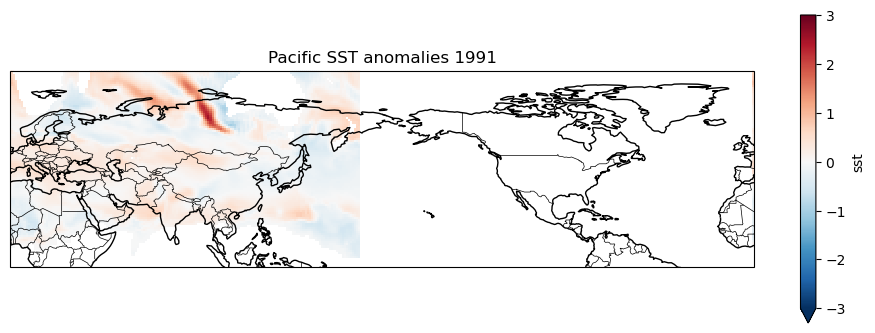

In [11]:
sst = "sst"
temp_surf_ocean = ds[sst]
sst_1991 = temp_surf_ocean.sel(time=slice("1991-01", "1991-12"))
baseline = temp_surf_ocean.groupby("time.month").mean("time")            # baseline = the whole dataset mean
sst_anom = sst_1991.groupby("time.month") - baseline

sst_anom_dec = sst_anom.mean(dim="time")
pacific = sst_anom_dec.sel(y=slice(35, -35), x=slice(120, 290))          # lon: (120, 290), lat: (-35, 35)
pacific = pacific.sortby("y")

plt.figure(figsize=(12,4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
pacific.plot(ax=ax, transform=ccrs.PlateCarree(),
             cmap="RdBu_r", vmin=-3, vmax=3, add_colorbar=True)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Pacific SST anomalies 1991")
plt.show()

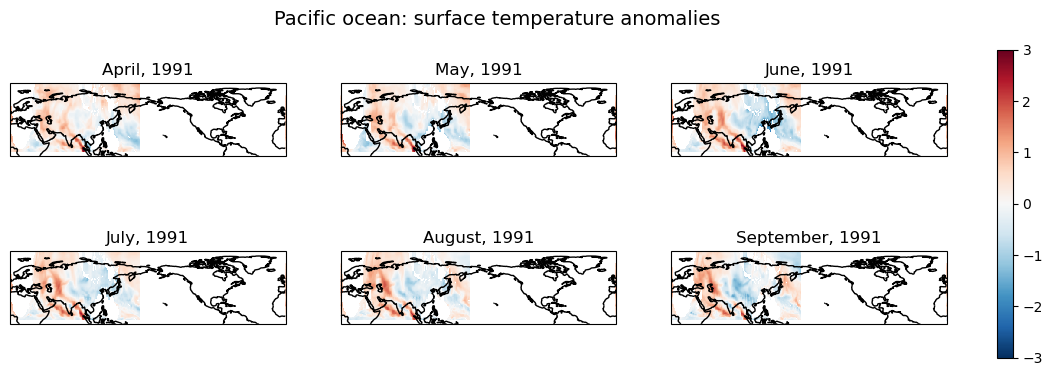

In [8]:
months_eruption = [4, 5, 6, 7, 8, 9]                                    # april, may, june, july, august, september
nino_y_min, nino_y_max = 150, 250                                       # -5 to 5 lat
nino_x_min, nino_x_max = 100, 200                                       # 190 to 240 lon

fig, axes = plt.subplots(2, 3, figsize=(13, 4),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)},
    sharex=True, sharey=True
)
axes = axes.flatten()

for ax, month in zip(axes, months_eruption):
    sst_month = sst_anom.sel(time=sst_anom["time.month"] == month)
    sst_month_mean = sst_month.mean(dim="time")
    pacific_month = sst_month_mean.sel(y=slice(100, 300), x=slice(120, 290))

    pcm = pacific_month.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-3, vmax=3,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_title(f"{calendar.month_name[month]}, 1991")

    rect = Rectangle(
        (nino_x_min, nino_y_min),
        nino_x_max - nino_x_min,
        nino_y_max - nino_y_min,
        facecolor='none',
        edgecolor='black',
        linewidth=1.5,
        linestyle='--',
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(rect)


fig.suptitle("Pacific ocean: surface temperature anomalies", fontsize=14)
cbar = fig.colorbar(pcm, ax=axes, orientation="vertical", fraction=0.02)
plt.show()

In [9]:
baseline = temp_surf_ocean.groupby("time.month").mean("time")
sst_anom = temp_surf_ocean.groupby("time.month") - baseline
sst_enso = sst_anom.sel(lon=slice(nino_x_min, nino_x_max), lat=slice(nino_y_min, nino_y_max))
sst_enso = sst_enso.mean(dim=["lat", "lon"])

time = sst_enso["time"].values
values = sst_enso.values
threshold = 0.9

plt.figure(figsize=(12,5))
plt.plot(time, values, color="deepskyblue", label="NorESM2.3")

plt.fill_between(
    time, threshold, values,
    where=values >= threshold,
    color="lightcoral"
)
plt.fill_between(
    time, -threshold, values,
    where=values <= -threshold,
    color="lightblue"
)

plt.fill_between(
    time, 0, values,
    where=values >= 0,
    color='lightcoral',
    alpha=0.4
)

plt.fill_between(
    time, 0, values,
    where=values <= 0,
    color='lightblue',
    alpha=0.4
)

plt.axhline(threshold, color='gray', linestyle='--')
plt.axhline(-threshold, color='gray', linestyle='--')
plt.axvline(cftime.DatetimeNoLeap(1991, 6, 1), color='gray', linestyle='--')
plt.text(cftime.DatetimeNoLeap(1991, 7, 1), 1.5, 'Pinatubo', rotation=90, color='k')
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.ylabel("temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("Niño3.4 Surface Temperature Anomalies")
plt.xlim(time[0], time[-1])
plt.legend()
plt.show()

KeyError: "'lon' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 240, 'y': 385, 'x': 360})"